In [1]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/"



Mounted at /content/drive


In [2]:
!pip install ultralytics -q
!pip install paddleocr -q
!pip install paddlepaddle -q
!pip install manga-ocr -q
!pip install opencv-python-headless -q
!pip install pillow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 117.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.

In [3]:
import os
import cv2
import json
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from ultralytics import YOLO
from paddleocr import PaddleOCR
from manga_ocr import MangaOcr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


РАСПАКОВКА АРХИВА

In [4]:
zip_path = "/content/drive/MyDrive/MangaLang.zip"

extract_path = "/content/MangaLang"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Архив распакован")

Архив распакован


ЗАГРУЗКА YOLO

In [5]:
from ultralytics import YOLO

# новая обученная модель
MODEL_PATH = "/content/drive/MyDrive/best_yolo_model.pt"

model = YOLO(MODEL_PATH)

print("YOLO загружена.")

YOLO загружена.


 ВЫБОР ЯЗЫКА

In [6]:
LANGUAGES = {

    "0":{
        "name":"English",
        "code":"en",
        "folder":"English",
        "ocr":"easyocr"
    },

    "1":{
        "name":"Vietnamese",
        "code":"vi",
        "folder":"Vietnam",
        "ocr":"easyocr"
    }
}

In [7]:
print("Доступные языки")

for k,v in LANGUAGES.items():
    print(k, v["name"])

lang_choice = input("Выберите язык: ").strip()

selected_lang = LANGUAGES[lang_choice]

print(selected_lang["name"])

Доступные языки
0 English
1 Vietnamese
Выберите язык: 0
English


ПОИСК ИЗОБРАЖЕНИЙ

In [8]:
base_path = "/content/MangaLang/MangaLang"

lang_folder = os.path.join(
    base_path,
    selected_lang["folder"]
)

test_images = []

for root, dirs, files in os.walk(lang_folder):

    for file in files:

        if file.lower().endswith(
            (".jpg",".jpeg",".png")
        ):

            test_images.append(
                os.path.join(root,file)
            )

print("Найдено:", len(test_images))

Найдено: 7


 Детектирование пузырей и текста

In [9]:
import cv2
import os
from pathlib import Path

# ----------------------------------------
# настройки
# ----------------------------------------

IMAGE_FOLDER = "/content/images"

# минимальная уверенность

BUBBLE_CONF = 0.30
TEXT_CONF   = 0.25

# ----------------------------------------

def box_inside(box_small, box_big, margin=5):
    """
    Проверяет находится ли текст внутри пузыря.
    """

    sx1, sy1, sx2, sy2 = box_small
    bx1, by1, bx2, by2 = box_big

    return (
        sx1 >= bx1-margin and
        sy1 >= by1-margin and
        sx2 <= bx2+margin and
        sy2 <= by2+margin
    )

# ----------------------------------------

all_pages = []

# ----------------------------------------

test_images = sorted(test_images)

for image_path in test_images:

    image_name = os.path.basename(image_path)

    image = cv2.imread(image_path)

    if image is None:
        print(f"Не удалось открыть {image_path}")
        continue

    h, w = image.shape[:2]

    result = model.predict(
        image,
        conf=min(BUBBLE_CONF, TEXT_CONF),
        verbose=False
    )[0]

    bubbles=[]
    texts=[]

    # ------------------------------------

    for box in result.boxes:

        cls=int(box.cls[0])

        conf=float(box.conf[0])

        x1,y1,x2,y2=map(int,box.xyxy[0])

        if cls==0 and conf>=BUBBLE_CONF:

            bubbles.append({
                "bbox":[x1,y1,x2,y2],
                "confidence":conf
            })

        elif cls==1 and conf>=TEXT_CONF:

            texts.append({
                "bbox":[x1,y1,x2,y2],
                "confidence":conf
            })

    # ------------------------------------
    # определяем текст внутри пузыря
    # ------------------------------------

    bubble_texts=[]

    outside_texts=[]

    for t in texts:

        inside=False

        for b in bubbles:

            if box_inside(t["bbox"],b["bbox"]):

                bubble_texts.append(t)

                inside=True

                break

        if not inside:

            outside_texts.append(t)

    # ------------------------------------

    page={

        "image":image_name,

        "bubbles":bubbles,

        "texts_in_bubbles":bubble_texts,

        "texts_outside":outside_texts

    }

    all_pages.append(page)

# ----------------------------------------

print("Страниц:",len(all_pages))

print()


Страниц: 7



In [10]:
print("selected_lang =", selected_lang)
print("type =", type(selected_lang))
print("keys =", selected_lang.keys())
print("code =", selected_lang.get("code"))

selected_lang = {'name': 'English', 'code': 'en', 'folder': 'English', 'ocr': 'easyocr'}
type = <class 'dict'>
keys = dict_keys(['name', 'code', 'folder', 'ocr'])
code = en


OCR

In [11]:
import os
import re
import json
import unicodedata

import cv2
import numpy as np

from PIL import Image
!pip install easyocr -q
import easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.5 MB/s eta 0:00:00


In [12]:
BUBBLE_CLASS = 0
TEXT_CLASS = 1

BUBBLE_CONF = 0.30
TEXT_CONF = 0.25

In [13]:
# Функция проверки "текст внутри пузыря"
def text_inside_bubble(text_box, bubble_box):

    tx1, ty1, tx2, ty2 = text_box
    bx1, by1, bx2, by2 = bubble_box

    cx = (tx1 + tx2) / 2
    cy = (ty1 + ty2) / 2

    return (
        bx1 <= cx <= bx2 and
        by1 <= cy <= by2
    )

In [14]:
print(easyocr.__version__)

1.7.2


In [15]:
# =====================================================
#  НАСТРОЙКА OCR
# =====================================================

print("\n" + "=" * 60)
print("НАСТРОЙКА OCR")
print("=" * 60)

lang_code = selected_lang.get("code")

print("Язык:", lang_code)

if lang_code == "ja":

    from manga_ocr import MangaOcr

    ocr = MangaOcr()
    ocr_engine_type = "manga"

else:

    lang_list = [lang_code]

    if lang_code in ["vi", "ru"]:
        lang_list.append("en")

    print("OCR languages:", lang_list)

    reader = easyocr.Reader(
        lang_list,
        gpu=False,
        verbose=False
    )

    ocr = reader
    ocr_engine_type = "easyocr"

print("OCR готов")


НАСТРОЙКА OCR
Язык: en
OCR languages: ['en']


OCR готов


In [16]:
# =====================================================
# БАЗОВАЯ ОЧИСТКА ТЕКСТА
# =====================================================

def clean_text(text):
    if text is None:
        return ""

    text = unicodedata.normalize("NFC", text)
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


Предобработка для OCR

In [17]:
def preprocess_variant1(img):
    if img is None or img.size == 0:
        return img

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    h, w = gray.shape
    scale = 2 if max(h, w) >= 120 else 3
    gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    return gray

In [18]:
def preprocess_variant2(img):
    if img is None or img.size == 0:
        return img

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    gray = clahe.apply(gray)
    gray = cv2.bilateralFilter(gray, d=5, sigmaColor=35, sigmaSpace=35)

    h, w = gray.shape
    scale = 2 if max(h, w) >= 120 else 3
    gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    return gray

In [19]:
def preprocess_variant3(img):
    if img is None or img.size == 0:
        return img

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    h, w = gray.shape
    scale = 2 if max(h, w) >= 120 else 3
    gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    blur = cv2.GaussianBlur(gray, (0, 0), 1.0)
    gray = cv2.addWeighted(gray, 1.5, blur, -0.5, 0)

    return gray

In [20]:
def preprocess_variant4(img):
    """
    Вариант 4: Адаптивная пороговая обработка + удаление шума
    Хорошо работает для текста на сложном фоне
    """
    if img is None or img.size == 0:
        return img

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Удаление шума
    gray = cv2.fastNlMeansDenoising(gray, None, 10, 7, 21)

    # Адаптивная пороговая обработка
    gray = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    # Инверсия (если текст темный на светлом фоне)
    # gray = cv2.bitwise_not(gray)

    # Увеличение
    h, w = gray.shape
    scale = 2 if max(h, w) >= 120 else 3
    gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    return gray

In [21]:
import re

In [22]:
VIET_CHARS = set(
    "ăâêôơưđ"
    "ĂÂÊÔƠƯĐ"
    "áàảãạấầẩẫậắằẳẵặ"
    "éèẻẽẹếềểễệ"
    "íìỉĩị"
    "óòỏõọốồổỗộớờởỡợ"
    "úùủũụứừửữự"
    "ýỳỷỹỵ"
)

In [23]:
def score_vietnamese_text(text):

    if not text:
        return -1000

    score = 0

    # -------------------------
    # длина
    # -------------------------

    score += len(text)

    # -------------------------
    # настоящие вьетнамские буквы
    # -------------------------

    for ch in text:

        if ch in VIET_CHARS:
            score += 8

    # -------------------------
    # обычные латинские буквы
    # -------------------------

    latin = sum(
        c.isalpha()
        for c in text
    )

    score += latin

    # -------------------------
    # штраф за мусор
    # -------------------------

    bad = "|[]{}\\/"

    for ch in bad:
        score -= text.count(ch) * 12

    # -------------------------
    # OCR очень любит выдавать
    # одиночные I l 1
    # -------------------------

    score -= text.count("|") * 15

    score -= text.count("1") * 6

    # -------------------------
    # если слишком мало букв
    # -------------------------

    letters = sum(
        c.isalpha()
        for c in text
    )

    if letters < 3:
        score -= 30

    return score

In [24]:
def choose_best_result(candidates, lang_code):
    """Выбирает лучший результат в зависимости от языка"""
    best_text = ""
    best_score = -999999

    for txt in candidates:
        txt = clean_text(txt)

        if lang_code == "vi":
            txt = apply_ocr_fixes(txt)
            s = score_vietnamese_text(txt)
        else:
            # Для английского и других языков
            s = len(txt)  # Просто выбираем самый длинный текст
            # Штраф за мусорные символы
            bad = "|[]{}\\<>"
            for ch in bad:
                s -= txt.count(ch) * 10

        if s > best_score:
            best_score = s
            best_text = txt

    return best_text

In [25]:
def fix_common_ocr_punctuation(text):

    text = text.replace(";..", ".")
    text = text.replace("..", ".")
    text = text.replace(",,", ",")
    text = text.replace("::", ":")

    return text

In [26]:
# =====================================================
# ENGLISH POSTPROCESS
# =====================================================

def clean_english_text(text):
    """
    Минимальная очистка английского текста
    Без агрессивных замен
    """
    if not text:
        return ""

    # Убрать лишние пробелы
    text = re.sub(r"\s+", " ", text)

    # Убрать пробел перед пунктуацией
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)

    # Восстановить пробелы после пунктуации
    text = re.sub(r"([.,!?;:])([A-Za-z])", r"\1 \2", text)

    return text.strip()

def postprocess_english(text):
    """
    Минимальная пост-обработка английского текста
    Без хардкодных замен
    """
    if not text:
        return text

    # Убрать повторные пробелы
    text = re.sub(r"\s+", " ", text)

    # Убрать мусорные символы по краям
    text = text.strip(" _-~|")

    # Убрать случайные цифры в конце слов (частая ошибка OCR)
    text = re.sub(r'([A-Za-z])\d+\b', r'\1', text)

    # Исправить распространенные замены (только безопасные)
    text = text.replace("'", "'")  # Нормализация апострофа

    # Если текст содержит много цифр и символов, возможно это мусор
    # Проверяем: если более 30% символов - не буквы
    alpha_count = sum(c.isalpha() for c in text)
    total_count = len(text)
    if total_count > 0 and alpha_count / total_count < 0.3:
        # Слишком много мусора - возвращаем пустую строку
        return ""

    return text.strip()

def normalize_english_case(text):
    """
    Нормализация регистра для английского
    """
    if not text:
        return text

    # Если текст полностью заглавный и длинный - делаем title
    alpha_count = sum(c.isalpha() for c in text)
    if alpha_count == 0:
        return text

    upper_count = sum(c.isupper() for c in text if c.isalpha())
    upper_ratio = upper_count / alpha_count

    if upper_ratio > 0.85:
        text = text.title()

    return text


Функция OCR

In [27]:
def ocr_text_box(text_img):
    try:
        if text_img is None or text_img.size == 0:
            return ""

        variants = [
            preprocess_variant1(text_img),
            preprocess_variant2(text_img),
            preprocess_variant3(text_img),
            preprocess_variant4(text_img)
        ]

        candidates = []

        if ocr_engine_type == "manga":
            for img in variants:
                try:
                    pil = Image.fromarray(img)
                    txt = ocr(pil)
                    txt = clean_text(txt)
                    candidates.append(txt)
                except:
                    pass

        else:
            kwargs = {
                "detail": 0,
                "paragraph": False
            }

            if selected_lang["code"] == "en":
                kwargs.update({
                    "decoder": "beamsearch",
                    "beamWidth": 10,
                    "rotation_info": [0, 180]
                })
            elif selected_lang["code"] == "vi":
                kwargs.update({
                    "decoder": "greedy"
                })

            for img in variants:
                try:
                    result = ocr.readtext(img, **kwargs)
                    txt = " ".join(result)
                    txt = clean_text(txt)
                    candidates.append(txt)
                except:
                    pass

        if len(candidates) == 0:
            return ""

        # Выбираем лучший результат
        text = choose_best_result(candidates, selected_lang["code"])

        # Пост-обработка для английского
        if selected_lang["code"] == "en":
            text = clean_english_text(text)
            text = postprocess_english(text)
            text = fix_common_ocr_punctuation(text)
            text = normalize_english_case(text)

        # Пост-обработка для вьетнамского
        elif selected_lang["code"] == "vi":
            text = apply_ocr_fixes(text)

        return text

    except Exception as e:
        print("OCR:", e)
        return ""

In [28]:
OCR_FIXES = {

    "ĐLỢC": "ĐƯỢC",
    "ĐƯỔC": "ĐƯỢC",
    "ĐUBC": "ĐƯỢC",

    "THLỜNG": "THƯỜNG",
    "THL": "THƯ",

    "CHLYỆN": "CHUYỆN",

    "KIỂL": "KIỂU",

    "TRUYềN": "TRUYỀN",

    "NHL": "NHI",

    "TRL": "TRƯ",

    "CL": "CƯ",

    "ĐL": "ĐƯ",

    "DL": "ĐƯ",

    "Cf": "CỨ",

    "CZ": "CŨ",

    "MỔ": "MƠ",

    "MÓl": "MỚI",

    "TRƯÓC": "TRƯỚC",

    "ĐẩU": "ĐẦU",

    "RổI": "RỒI",

    "Rồl": "Rồi",

    "ĐỢl": "ĐỢI",

    "VẨn": "VẪN",

    "CẬL": "CẬU",

    "NHIỀL": "NHIỀU",

    "THÔL": "THÔI",

    "NUbNG": "NƯƠNG"
}

def apply_ocr_fixes(text):

    if not text:
        return text

    text = unicodedata.normalize(
        "NFC",
        text
    )

    # ТОЛЬКО ОТКРЫВАЮЩАЯ СКОБКА ( → C
    VN_VOWELS = "AÀÁẢÃẠĂẰẮẲẴẶÂẤẦẨẪẬEÈÉẺẼẸÊỀẾỂỄỆIÌÍỈĨỊOÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢUÙÚỦŨỤƯỪỨỬỮỰYỲÝỶỸỴ"

    text = re.sub(fr'\(([{VN_VOWELS}])', r'C\1', text)

    # исправления только целых слов

    for wrong, right in OCR_FIXES.items():

        text = re.sub(

            rf"\b{re.escape(wrong)}\b",

            right,

            text

        )

    # частые ошибки OCR

    text = re.sub(
        r"(?<=\w)l(?=[ÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚĂĐĨŨƠƯẠ-ỹ])",
        "I",
        text
    )

    text = re.sub(
        r"(?<=\w)I(?=[a-zàáảãạăâđêôơư])",
        "l",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = re.sub(
        r"\s+([,.!?;:])",
        r"\1",
        text
    )

    return text.strip()

In [29]:
# =====================================================
# СОРТИРОВКА ТЕКСТОВ ВНУТРИ ПУЗЫРЯ
# =====================================================

def sort_text_boxes(text_items, y_threshold=20):

    if len(text_items) <= 1:
        return text_items

    # сначала сортируем сверху вниз

    text_items = sorted(
        text_items,
        key=lambda x: (
            x["bbox"][1],
            x["bbox"][0]
        )
    )

    rows = []

    for item in text_items:

        x1, y1, x2, y2 = item["bbox"]

        center_y = (y1 + y2) / 2

        found = False

        for row in rows:

            if abs(center_y - row["center"]) < y_threshold:

                row["items"].append(item)

                row["center"] = np.mean([

                    (t["bbox"][1] + t["bbox"][3]) / 2

                    for t in row["items"]

                ])

                found = True

                break

        if not found:

            rows.append({

                "center": center_y,

                "items": [item]

            })

    result = []

    rows = sorted(
        rows,
        key=lambda r: r["center"]
    )

    for row in rows:

        row["items"] = sorted(

            row["items"],

            key=lambda t: t["bbox"][0]

        )

        result.extend(row["items"])

    return result

In [30]:
# =====================================================
# СКЛЕЙКА ТЕКСТА
# =====================================================

def merge_text_items(text_items):

    if len(text_items) == 0:
        return ""

    text_items = sort_text_boxes(text_items)

    parts = []

    for item in text_items:

        txt = item["text"].strip()

        if txt:

            parts.append(txt)

    text = " ".join(parts)

    text = re.sub(r"\s+", " ", text)

    text = text.replace(" ,", ",")

    text = text.replace(" .", ".")

    text = text.replace(" !", "!")

    text = text.replace(" ?", "?")

    text = text.replace(" ;", ";")

    text = text.replace(" :", ":")

    return text.strip()

Основной цикл обработки

In [31]:
all_pages = []

for img_path in test_images:

    print("\n" + "=" * 70)
    print(os.path.basename(img_path))
    print("=" * 70)

    img = cv2.imread(img_path)

    # Используем уже загруженное изображение
    result = model(img)[0]

    bubble_boxes = []
    text_boxes = []

    # ---------------------------------------------------
    # разделяем классы
    # ---------------------------------------------------

    for box in result.boxes:

        cls = int(box.cls.item())
        conf = float(box.conf.item())

        x1, y1, x2, y2 = map(
            int,
            box.xyxy[0]
        )

        if cls == BUBBLE_CLASS:

            if conf >= BUBBLE_CONF:

                bubble_boxes.append({

                    "bbox": [x1, y1, x2, y2],
                    "conf": conf

                })

        elif cls == TEXT_CLASS:

            if conf >= TEXT_CONF:

                text_boxes.append({

                    "bbox": [x1, y1, x2, y2],
                    "conf": conf

                })

    print("Пузырей:", len(bubble_boxes))
    print("Текстовых боксов:", len(text_boxes))

    page_data = []

    # Счетчик для ID текста (глобальный для страницы)
    text_id_counter = 1

    # ---------------------------------------------------
    # OCR каждого пузыря
    # ---------------------------------------------------

    for bubble in bubble_boxes:

        texts_inside = []

        for text in text_boxes:

            if not text_inside_bubble(
                text["bbox"],
                bubble["bbox"]
            ):
                continue

            tx1, ty1, tx2, ty2 = text["bbox"]

            # небольшой запас вокруг текста

            pad = 3

            tx1 = max(0, tx1 - pad)
            ty1 = max(0, ty1 - pad)

            tx2 = min(img.shape[1], tx2 + pad)
            ty2 = min(img.shape[0], ty2 + pad)

            crop = img[
                ty1:ty2,
                tx1:tx2
            ]

            recognized = ocr_text_box(crop)

            recognized = recognized.strip()

            # пустой результат

            if recognized == "":
                continue

            # одиночный мусор

            if len(recognized) == 1 and recognized not in [
                "?",
                "!",
                ".",
                "…"
            ]:
                continue

            # =============================================
            # ДОБАВЛЯЕМ ID ДЛЯ КАЖДОГО ТЕКСТОВОГО БОКСА
            # =============================================

            texts_inside.append({

                "bbox": text["bbox"],
                "text": recognized,
                "text_id": text_id_counter  # Уникальный ID для каждого текста

            })

            text_id_counter += 1  # Увеличиваем счетчик

        # ------------------------------------------------
        # сортировка
        # ------------------------------------------------

        texts_inside = sort_text_boxes(
            texts_inside
        )

        # ------------------------------------------------
        # убрать случайные дубли OCR
        # ------------------------------------------------

        unique = []

        seen = set()

        for item in texts_inside:

            txt = item["text"]

            if txt in seen:
                continue

            seen.add(txt)

            unique.append(item)

        texts_inside = unique

        # ------------------------------------------------
        # объединение текста
        # ------------------------------------------------

        full_text = merge_text_items(
            texts_inside
        )

        page_data.append({

            "bbox": bubble["bbox"],

            "texts": texts_inside,

            "source_text": full_text,

            "confidence": bubble["conf"]

        })

    # ---------------------------------------------------
    # вывод OCR
    # ---------------------------------------------------

    for i, bubble in enumerate(page_data):

        print()

        print(f"Пузырь {i + 1}")

        print(bubble["source_text"])

        # Выводим ID каждого текста в пузыре
        for text_item in bubble["texts"]:
            print(f"  ID {text_item['text_id']}: {text_item['text']}")

    # ---------------------------------------------------
    # сохранить страницу
    # ---------------------------------------------------

    all_pages.append({

        "image": os.path.basename(img_path),

        "texts": page_data

    })


01.jpg
Пузырей: 1
Текстовых боксов: 1


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Пузырь 1
Thank You Very Muchi
  ID 1: Thank You Very Muchi

02.jpg
Пузырей: 1
Текстовых боксов: 1

Пузырь 1
That Must Be Why Your Body Cant Feel Pain_ 0
  ID 1: That Must Be Why Your Body Cant Feel Pain_ 0

03.jpg
Пузырей: 2
Текстовых боксов: 2

Пузырь 1
it'd BE AN I30OW 010 USED FoR SPACE TOLRS, But I Might OL 31a 33 3NO JN3d FpoM OVER- 'Sv3S
  ID 1: it'd BE AN I30OW 010 USED FoR SPACE TOLRS, But I Might OL 31a 33 3NO JN3d FpoM OVER- 'Sv3S

Пузырь 2
Yo KnOW WHAT? Let ME ASK AROUND:
  ID 2: Yo KnOW WHAT? Let ME ASK AROUND:

04.jpg
Пузырей: 1
Текстовых боксов: 1


/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:221: RuntimeWarning: overflow encountered in scalar add
  curr.entries[labeling].prTotal += prBlank + prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:248: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prNonBlank += prNonBlank
/usr/local/lib/python3.12/dist-packages/easyocr/utils.py:249: RuntimeWarning: overflow encountered in scalar add
  curr.entries[newLabeling].prTotal += prNonBlank



Пузырь 1
Instructor, WhY DO You ALWAYS HAVE THAT Look On Your FACE?
  ID 1: Instructor, WhY DO You ALWAYS HAVE THAT Look On Your FACE?

05.jpg
Пузырей: 5
Текстовых боксов: 8

Пузырь 1
Could You Say That If He Killed Your Family?
  ID 1: Could You Say That If He Killed Your Family?

Пузырь 2
W; I" COUNTING ON YOU TO 'aw dOls
  ID 2: W; I" COUNTING ON YOU TO 'aw dOls

Пузырь 3
If You Let Nmo &Nok Feelings Drive You To Kill, Then You Re No Better Than Him:
  ID 3: If You Let Nmo &Nok Feelings Drive You To Kill, Then You Re No Better Than Him:

Пузырь 4
Probably Not:.
  ID 4: Probably Not:.

Пузырь 5
He'S Gotta Face Up To His Crimes:
  ID 5: He'S Gotta Face Up To His Crimes:

06.jpg
Пузырей: 2
Текстовых боксов: 2

Пузырь 1
Then, As If They Had Been Waiting For This,
  ID 1: Then, As If They Had Been Waiting For This,

Пузырь 2
Demon King Worshippers Rose Up
  ID 2: Demon King Worshippers Rose Up

07.jpg
Пузырей: 2
Текстовых боксов: 2

Пузырь 1
HAVE AND I WANT To Mope I MOH Os 'nok 1731 Lh

In [32]:
import json

with open(
    "ocr_result.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        all_pages,
        f,
        ensure_ascii=False,
        indent=4
    )

print("Готово.")
print("Страниц:", len(all_pages))

Готово.
Страниц: 7


ПЕРЕВОД

In [33]:
#  Установка
!pip install deep-translator -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.2 MB/s eta 0:00:00


In [34]:
# Импорт
import json
import time

from deep_translator import GoogleTranslator

In [35]:
# Язык перевода
TARGET_LANGUAGE = "ru"

In [36]:
# Загружаем OCR JSON
OCR_JSON = "ocr_result.json"

with open(
    OCR_JSON,
    "r",
    encoding="utf-8"
) as f:

    pages = json.load(f)

print("Страниц:", len(pages))

Страниц: 7


In [37]:
# Создаем переводчик
translator = GoogleTranslator(
    source="auto",
    target=TARGET_LANGUAGE
)

In [38]:
# Перевод
for page in pages:

    print()
    print("=" * 60)
    print(page["image"])

    for bubble in page["texts"]:

        src = bubble["source_text"].strip()

        if src == "":
            bubble["translated_text"] = ""
            continue

        try:

            tr = translator.translate(src)

        except Exception:

            tr = ""

        bubble["translated_text"] = tr

        print()
        print("SOURCE:")
        print(src)

        print("TRANSLATED:")
        print(tr)

        time.sleep(0.25)


01.jpg

SOURCE:
Thank You Very Muchi
TRANSLATED:
Большое спасибо Мучи

02.jpg

SOURCE:
That Must Be Why Your Body Cant Feel Pain_ 0
TRANSLATED:
Должно быть, именно поэтому ваше тело не чувствует боли_ 0

03.jpg

SOURCE:
it'd BE AN I30OW 010 USED FoR SPACE TOLRS, But I Might OL 31a 33 3NO JN3d FpoM OVER- 'Sv3S
TRANSLATED:
ЭТО БЫЛ I30OW 010, ИСПОЛЬЗУЕМЫЙ ДЛЯ КОСМИЧЕСКИХ TOLRS, но я мог бы OL 31a 33 3NO JN3d FpoM OVER- 'Sv3S

SOURCE:
Yo KnOW WHAT? Let ME ASK AROUND:
TRANSLATED:
Эй, знаешь ЧТО? Позвольте МНЕ СПРОСИТЬ:

04.jpg

SOURCE:
Instructor, WhY DO You ALWAYS HAVE THAT Look On Your FACE?
TRANSLATED:
Инструктор, ПОЧЕМУ У ТЕБЯ ВСЕГДА ТАКОЕ ВЫГЛЯДЕНИЕ НА ЛИЦЕ?

05.jpg

SOURCE:
Could You Say That If He Killed Your Family?
TRANSLATED:
Могли бы вы сказать это, если бы он убил вашу семью?

SOURCE:
W; I" COUNTING ON YOU TO 'aw dOls
TRANSLATED:
В; Я РАСЧИТАЮ НА ВАС, ой, куклы

SOURCE:
If You Let Nmo &Nok Feelings Drive You To Kill, Then You Re No Better Than Him:
TRANSLATED:
Если вы позволите

In [39]:
# Сохранение
OUTPUT_JSON = "translated_result.json"

with open(
    OUTPUT_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        pages,
        f,
        ensure_ascii=False,
        indent=4
    )

print()
print("Сохранено:", OUTPUT_JSON)


Сохранено: translated_result.json


Отрисовка перевода

In [40]:
# =====================================================
#
# Импорты и подготовка проекта
# =====================================================

import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# =====================================================
# Путь к шрифту
# =====================================================

FONT_PATH = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"

if not os.path.exists(FONT_PATH):
    # Для Colab можно скачать шрифт
    !wget -q https://github.com/googlefonts/noto-cjk/raw/main/Sans/SubsetOTF/NotoSansCJK-Regular.ttc -O /content/NotoSansCJK-Regular.ttc
    FONT_PATH = "/content/NotoSansCJK-Regular.ttc"

print("Шрифт:", FONT_PATH)

# =====================================================
# Загружаем translated_result.json
# =====================================================

JSON_PATH = "translated_result.json"

with open(JSON_PATH, "r", encoding="utf-8") as f:
    pages = json.load(f)

print(f"JSON загружен. Страниц: {len(pages)}")

# =====================================================
# Создаем словарь путей к изображениям
# =====================================================

image_dict = {}
for path in test_images:
    image_dict[os.path.basename(path)] = path

print(f"Изображений: {len(image_dict)}")

# Проверка соответствия
missing = [page["image"] for page in pages if page["image"] not in image_dict]
if missing:
    print("Не найдены:", missing)
else:
    print("Все изображения найдены.")

Шрифт: /usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf
JSON загружен. Страниц: 7
Изображений: 7
Все изображения найдены.


In [41]:
# =====================================================
#
# Работа с областями текста
# =====================================================

def get_merged_text_region(bubble):
    """
    Возвращает объединенную область всех текстовых боксов БЕЗ расширения
    (для отображения и рисования)
    """
    if len(bubble["texts"]) == 0:
        return bubble["bbox"]

    x1 = min(t["bbox"][0] for t in bubble["texts"])
    y1 = min(t["bbox"][1] for t in bubble["texts"])
    x2 = max(t["bbox"][2] for t in bubble["texts"])
    y2 = max(t["bbox"][3] for t in bubble["texts"])

    return [int(x1), int(y1), int(x2), int(y2)]

def get_text_region_with_padding(bubble, padding_ratio=0.08, expand_ratio=0.25):
    """
    Возвращает расширенную область для лучшего размещения текста
    (используется только для рисования, если нужно)
    """
    bx1, by1, bx2, by2 = bubble["bbox"]

    if len(bubble["texts"]) == 0:
        return [bx1, by1, bx2, by2]

    # Объединяем все текстовые боксы
    x1 = min(t["bbox"][0] for t in bubble["texts"])
    y1 = min(t["bbox"][1] for t in bubble["texts"])
    x2 = max(t["bbox"][2] for t in bubble["texts"])
    y2 = max(t["bbox"][3] for t in bubble["texts"])

    w = x2 - x1
    h = y2 - y1

    # Добавляем отступы
    padding = max(6, int(min(w, h) * padding_ratio))
    x1 -= padding
    y1 -= padding
    x2 += padding
    y2 += padding

    # Расширяем область
    dx = int(w * expand_ratio)
    dy = int(h * expand_ratio)
    x1 -= dx
    y1 -= dy
    x2 += dx
    y2 += dy

    # Ограничиваем границами пузыря
    x1 = max(x1, bx1)
    y1 = max(y1, by1)
    x2 = min(x2, bx2)
    y2 = min(y2, by2)

    return [int(x1), int(y1), int(x2), int(y2)]

def expand_bbox(bbox, image_shape, margin=8):
    """Расширяет область для очистки"""
    x1, y1, x2, y2 = bbox
    h, w = image_shape[:2]

    x1 = max(0, x1 - margin)
    y1 = max(0, y1 - margin)
    x2 = min(w - 1, x2 + margin)
    y2 = min(h - 1, y2 + margin)

    return [int(x1), int(y1), int(x2), int(y2)]

def estimate_background_color(image, bbox, border=3):
    """Определяет цвет фона по краям области"""
    x1, y1, x2, y2 = bbox
    h, w = image.shape[:2]

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w - 1, x2)
    y2 = min(h - 1, y2)

    pixels = []

    # Верх
    if y1 + border < y2:
        pixels.append(image[y1:y1+border, x1:x2])

    # Низ
    if y2 - border > y1:
        pixels.append(image[y2-border:y2, x1:x2])

    # Лево
    if x1 + border < x2:
        pixels.append(image[y1:y2, x1:x1+border])

    # Право
    if x2 - border > x1:
        pixels.append(image[y1:y2, x2-border:x2])

    pixels = [p.reshape(-1, 3) for p in pixels if p.size > 0]

    if len(pixels) == 0:
        return (255, 255, 255)

    pixels = np.concatenate(pixels, axis=0)
    color = np.median(pixels, axis=0)

    return tuple(map(int, color))

def clear_text_regions(image, page):
    """
    Очищает области текста внутри пузырей
    Использует ТУ ЖЕ область, что и для рисования
    """
    img = image.copy()

    for bubble in page["texts"]:
        # Используем ОБЪЕДИНЕННУЮ область (без расширения)
        region = get_merged_text_region(bubble)
        clear_region = expand_bbox(region, img.shape, margin=4)

        # Определяем цвет фона
        color = estimate_background_color(img, clear_region)

        # Заливаем область
        x1, y1, x2, y2 = clear_region
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness=-1)

    return img

print("Ячейка 2 готова.")

Ячейка 2 готова.


In [42]:
# =====================================================
#
# Движок рисования текста с улучшенным размещением
# =====================================================

def split_text_to_lines(text, draw, font, max_width):
    """Разбивает текст на строки по ширине"""
    words = text.split()
    if len(words) == 0:
        return []

    lines = []
    current = words[0]

    for word in words[1:]:
        candidate = current + " " + word
        bbox = draw.textbbox((0, 0), candidate, font=font)
        width = bbox[2] - bbox[0]

        if width <= max_width:
            current = candidate
        else:
            lines.append(current)
            current = word

    lines.append(current)
    return lines

def fit_font_size(text, draw, font_path, box_width, box_height, min_size=4, max_size=36):
    """
    Подбирает оптимальный размер шрифта с агрессивным уменьшением
    """
    best_font = None
    best_lines = None

    # Пробуем размеры от максимального к минимальному
    for size in range(max_size, min_size - 1, -1):
        try:
            font = ImageFont.truetype(font_path, size)
        except:
            font = ImageFont.load_default()

        lines = split_text_to_lines(text, draw, font, box_width - 4)

        # Проверяем ширину каждой строки
        fits_width = True
        for line in lines:
            bbox = draw.textbbox((0, 0), line, font=font)
            if bbox[2] - bbox[0] > box_width - 4:
                fits_width = False
                break

        if not fits_width:
            continue

        # Проверяем высоту
        line_bbox = draw.textbbox((0, 0), "Ag", font=font)
        line_height = line_bbox[3] - line_bbox[1]
        total_height = line_height * len(lines)

        if total_height <= box_height - 4:
            best_font = font
            best_lines = lines
            break

    # Если ничего не подошло - берем минимальный размер и обрезаем
    if best_font is None:
        try:
            best_font = ImageFont.truetype(font_path, min_size)
        except:
            best_font = ImageFont.load_default()

        best_lines = split_text_to_lines(text, draw, best_font, box_width - 4)

        # Обрезаем строки, если не помещаются
        line_bbox = draw.textbbox((0, 0), "Ag", font=best_font)
        line_height = line_bbox[3] - line_bbox[1]
        total_height = line_height * len(best_lines)

        while total_height > box_height - 4 and len(best_lines) > 1:
            best_lines = best_lines[:-1]
            total_height = line_height * len(best_lines)

        # Если все еще не помещается - обрезаем последнюю строку
        if total_height > box_height - 4 and len(best_lines) > 0:
            last_line = best_lines[-1]
            while len(last_line) > 1:
                last_line = last_line[:-1]
                bbox = draw.textbbox((0, 0), last_line + "...", font=best_font)
                if bbox[2] - bbox[0] <= box_width - 4:
                    best_lines[-1] = last_line + "..."
                    break

    return best_font, best_lines

def get_text_color(background_color):
    """
    Определяет цвет текста на основе яркости фона
    """
    brightness = 0.299 * background_color[0] + 0.587 * background_color[1] + 0.114 * background_color[2]

    if brightness > 128:
        return (0, 0, 0)      # Черный на светлом фоне
    else:
        return (255, 255, 255) # Белый на темном фоне

def estimate_background_color_clean(image, bbox, border=5):
    """
    Определяет цвет фона ТОЛЬКО по краям области (игнорируя текст в центре)
    """
    x1, y1, x2, y2 = bbox
    h, w = image.shape[:2]

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w - 1, x2)
    y2 = min(h - 1, y2)

    if x2 - x1 < 20 or y2 - y1 < 20:
        return (255, 255, 255)

    pixels = []

    # Размер области для анализа
    border = min(border, (y2 - y1) // 5, (x2 - x1) // 5)
    border = max(border, 3)

    # =============================================
    # Берем пиксели только с КРАЕВ
    # =============================================

    # Верхняя полоса
    if y1 + border < y2:
        roi = image[y1:y1+border, x1:x2]
        if roi.size > 0:
            pixels.append(roi.reshape(-1, 3))

    # Нижняя полоса
    if y2 - border > y1:
        roi = image[y2-border:y2, x1:x2]
        if roi.size > 0:
            pixels.append(roi.reshape(-1, 3))

    # Левая полоса
    if x1 + border < x2:
        roi = image[y1:y2, x1:x1+border]
        if roi.size > 0:
            pixels.append(roi.reshape(-1, 3))

    # Правая полоса
    if x2 - border > x1:
        roi = image[y1:y2, x2-border:x2]
        if roi.size > 0:
            pixels.append(roi.reshape(-1, 3))

    # =============================================
    # Добавляем УГЛЫ (там точно нет текста)
    # =============================================

    # Левый верхний угол
    if y1 + border < y2 and x1 + border < x2:
        roi = image[y1:y1+border, x1:x1+border]
        if roi.size > 0:
            pixels.append(roi.reshape(-1, 3))

    # Правый верхний угол
    if y1 + border < y2 and x2 - border > x1:
        roi = image[y1:y1+border, x2-border:x2]
        if roi.size > 0:
            pixels.append(roi.reshape(-1, 3))

    # Левый нижний угол
    if y2 - border > y1 and x1 + border < x2:
        roi = image[y2-border:y2, x1:x1+border]
        if roi.size > 0:
            pixels.append(roi.reshape(-1, 3))

    # Правый нижний угол
    if y2 - border > y1 and x2 - border > x1:
        roi = image[y2-border:y2, x2-border:x2]
        if roi.size > 0:
            pixels.append(roi.reshape(-1, 3))

    if len(pixels) == 0:
        return (255, 255, 255)

    all_pixels = np.concatenate(pixels, axis=0)

    if all_pixels.shape[0] == 0:
        return (255, 255, 255)

    # =============================================
    # Убираем выбросы (слишком темные/светлые пиксели)
    # =============================================

    brightness = 0.299 * all_pixels[:, 0] + 0.587 * all_pixels[:, 1] + 0.114 * all_pixels[:, 2]

    low = np.percentile(brightness, 10)
    high = np.percentile(brightness, 90)

    mask = (brightness >= low) & (brightness <= high)
    if np.any(mask):
        filtered_pixels = all_pixels[mask]
    else:
        filtered_pixels = all_pixels

    # Используем медиану
    color = np.median(filtered_pixels, axis=0)

    return tuple(map(int, color))

def put_text_in_bbox_improved(draw, text, bbox, font_path, bg_color=(255, 255, 255)):
    """
    Рисует текст в заданной области с автоматическим подбором цвета
    """
    if text.strip() == "":
        return

    x1, y1, x2, y2 = bbox
    width = x2 - x1
    height = y2 - y1

    if width < 10 or height < 10:
        return

    # Подбираем шрифт
    font, lines = fit_font_size(text, draw, font_path, width, height)

    # Определяем цвет текста
    text_color = get_text_color(bg_color)

    # Вычисляем высоту строки
    line_bbox = draw.textbbox((0, 0), "Ag", font=font)
    line_height = line_bbox[3] - line_bbox[1]

    total_height = line_height * len(lines)

    # Центрируем по вертикали
    y = y1 + (height - total_height) / 2

    # Определяем цвет обводки (контрастный к тексту)
    if text_color == (0, 0, 0):
        outline_color = (255, 255, 255)
    else:
        outline_color = (0, 0, 0)

    for line in lines:
        bbox_line = draw.textbbox((0, 0), line, font=font)
        line_width = bbox_line[2] - bbox_line[0]
        x = x1 + (width - line_width) / 2

        # Рисуем обводку (смещение на 1 пиксель)
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            draw.text((x + dx, y + dy), line, fill=outline_color, font=font)

        # Рисуем основной текст
        draw.text((x, y), line, fill=text_color, font=font)

        y += line_height

def clear_text_regions_improved(image, page):
    """
    Очищает области текста с улучшенным определением фона
    """
    img = image.copy()

    for bubble in page["texts"]:
        region = get_merged_text_region(bubble)
        clear_region = expand_bbox(region, img.shape, margin=4)

        # Определяем цвет фона (только по краям)
        color = estimate_background_color_clean(img, clear_region)

        # Заливаем область
        x1, y1, x2, y2 = clear_region
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness=-1)

    return img

print("Ячейка 3 готова.")

Ячейка 3 готова.


In [43]:
# =====================================================
#
# Построение страницы с улучшенной отрисовкой
# =====================================================

def draw_translation_page_improved(image, page):
    """
    Создает изображение с переводом (улучшенная версия)
    """
    # Очищаем оригинальный текст с улучшенным определением фона
    img = clear_text_regions_improved(image, page)

    # OpenCV -> PIL
    pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(pil)

    # Рисуем перевод
    for bubble in page["texts"]:
        text = bubble.get("edited_text", "").strip()
        if text == "":
            text = bubble.get("translated_text", "").strip()

        if text == "":
            continue

        # Получаем область текста
        region = get_merged_text_region(bubble)

        # Определяем цвет фона для этой области
        bg_color = estimate_background_color_clean(img, region)

        # Рисуем текст с автоматическим подбором цвета
        put_text_in_bbox_improved(draw, text, region, FONT_PATH, bg_color)

    # PIL -> OpenCV
    return cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

print("Ячейка 4 готова.")

Ячейка 4 готова.


In [44]:
# =====================================================
# ФУНКЦИЯ ОТРИСОВКИ СТРАНИЦЫ С ВОЗВРАТОМ КАРТИНКИ
# =====================================================

def display_and_get_translated_image(img, page):
    """
    Отображает страницу с оригиналом и переводом (с боксами и ID),
    возвращает чистую картинку с переводом (без боксов и ID)
    """
    # Копии для отрисовки
    img_original = img.copy()

    # Создаем перевод с улучшенной отрисовкой
    img_translated = draw_translation_page_improved(img, page)

    # Сохраняем чистую картинку с переводом (без боксов и ID)
    img_clean_translated = img_translated.copy()

    # =================================================
    # Рисуем боксы на ОБЕИХ картинках (для отображения)
    # =================================================

    for bubble in page["texts"]:
        # ---- Зеленый бокс пузыря ----
        bx1, by1, bx2, by2 = bubble["bbox"]

        for img_draw in [img_original, img_translated]:
            cv2.rectangle(
                img_draw,
                (bx1, by1),
                (bx2, by2),
                (0, 255, 0),  # Зеленый
                2
            )

        # ---- Красный бокс текста (объединенная область) ----
        region = get_merged_text_region(bubble)
        tx1, ty1, tx2, ty2 = region

        for img_draw in [img_original, img_translated]:
            cv2.rectangle(
                img_draw,
                (tx1, ty1),
                (tx2, ty2),
                (0, 0, 255),  # Красный
                2
            )

        # ---- Рисуем ID на правой картинке с желтым фоном ----
        for text_item in bubble["texts"]:
            text_id = text_item.get("text_id", 0)
            if text_id > 0:
                tx1, ty1, tx2, ty2 = text_item["bbox"]

                # Вычисляем размер бокса
                box_width = tx2 - tx1
                box_height = ty2 - ty1

                # Размер шрифта пропорционален размеру бокса
                font_scale = min(box_width, box_height) / 25
                font_scale = max(0.4, min(1.2, font_scale))
                thickness = max(1, int(font_scale * 2))

                # Текст ID
                id_text = f"ID:{text_id}"

                # Получаем размер текста для создания прямоугольника
                (text_width, text_height), baseline = cv2.getTextSize(
                    id_text,
                    cv2.FONT_HERSHEY_SIMPLEX,
                    font_scale,
                    thickness
                )

                # Позиция ID (над боксом, с отступом)
                id_x = tx1
                id_y = ty1 - 10

                # Если ID выходит за верхний край картинки
                if id_y < 10:
                    id_y = ty2 + 20  # Рисуем под боксом

                # Координаты для желтого прямоугольника
                rect_x1 = id_x - 4
                rect_y1 = id_y - text_height - 4
                rect_x2 = id_x + text_width + 4
                rect_y2 = id_y + 4

                # Желтый прямоугольник под ID
                cv2.rectangle(
                    img_translated,
                    (rect_x1, rect_y1),
                    (rect_x2, rect_y2),
                    (0, 255, 255),  # Желтый
                    -1  # Заливка
                )

                # Черная обводка текста
                cv2.putText(
                    img_translated,
                    id_text,
                    (id_x, id_y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    font_scale,
                    (0, 0, 0),
                    thickness + 2
                )

                # Основной текст ID (синий)
                cv2.putText(
                    img_translated,
                    id_text,
                    (id_x, id_y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    font_scale,
                    (255, 0, 0),
                    thickness
                )

    # =================================================
    # Отображаем
    # =================================================

    plt.figure(figsize=(18, 9))
    fig = plt.figure(figsize=(18, 9))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
    plt.title(f"{os.path.basename(page['image'])}  ORIGINAL\n(Зеленый = пузырь, Красный = текст)", fontsize=12)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_translated, cv2.COLOR_BGR2RGB))
    plt.title(f"{os.path.basename(page['image'])}  TRANSLATED\n(Зеленый = пузырь, Красный = текст, Синий = ID)", fontsize=12)
    plt.axis("off")

    plt.tight_layout()
    #plt.show()

    # Возвращаем чистую картинку с переводом (без боксов и ID)
    return img_clean_translated, fig

In [45]:
# =====================================================
# СОЗДАНИЕ ПАПКИ ДЛЯ СОХРАНЕНИЯ
# =====================================================

# Создаем папку для сохранения переведенных изображений
lang_name = selected_lang["name"].lower()
output_dir = f"/content/translated_img_{lang_name}"
os.makedirs(output_dir, exist_ok=True)
print(f" Папка для сохранения: {output_dir}")

 Папка для сохранения: /content/translated_img_english


Всего страниц: 7
Введите номер страницы для начала (1-7): 1


<Figure size 1800x900 with 0 Axes>

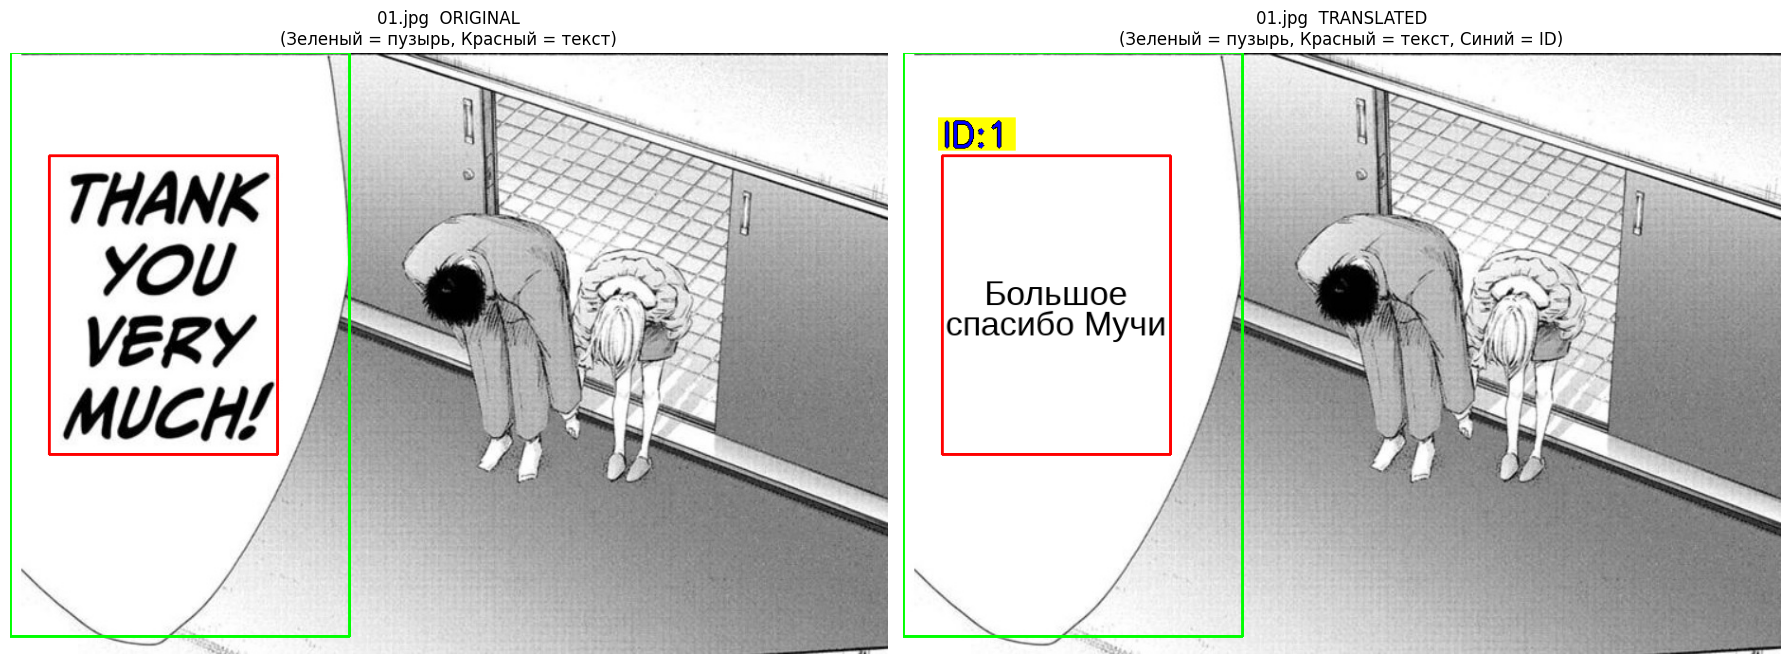


Страница 1/7
0 - редактировать
1 - сохранить и перейти дальше
2 - завершить работу
Ваш выбор: 1
 JPEG сохранён: 01.jpg


<Figure size 1800x900 with 0 Axes>

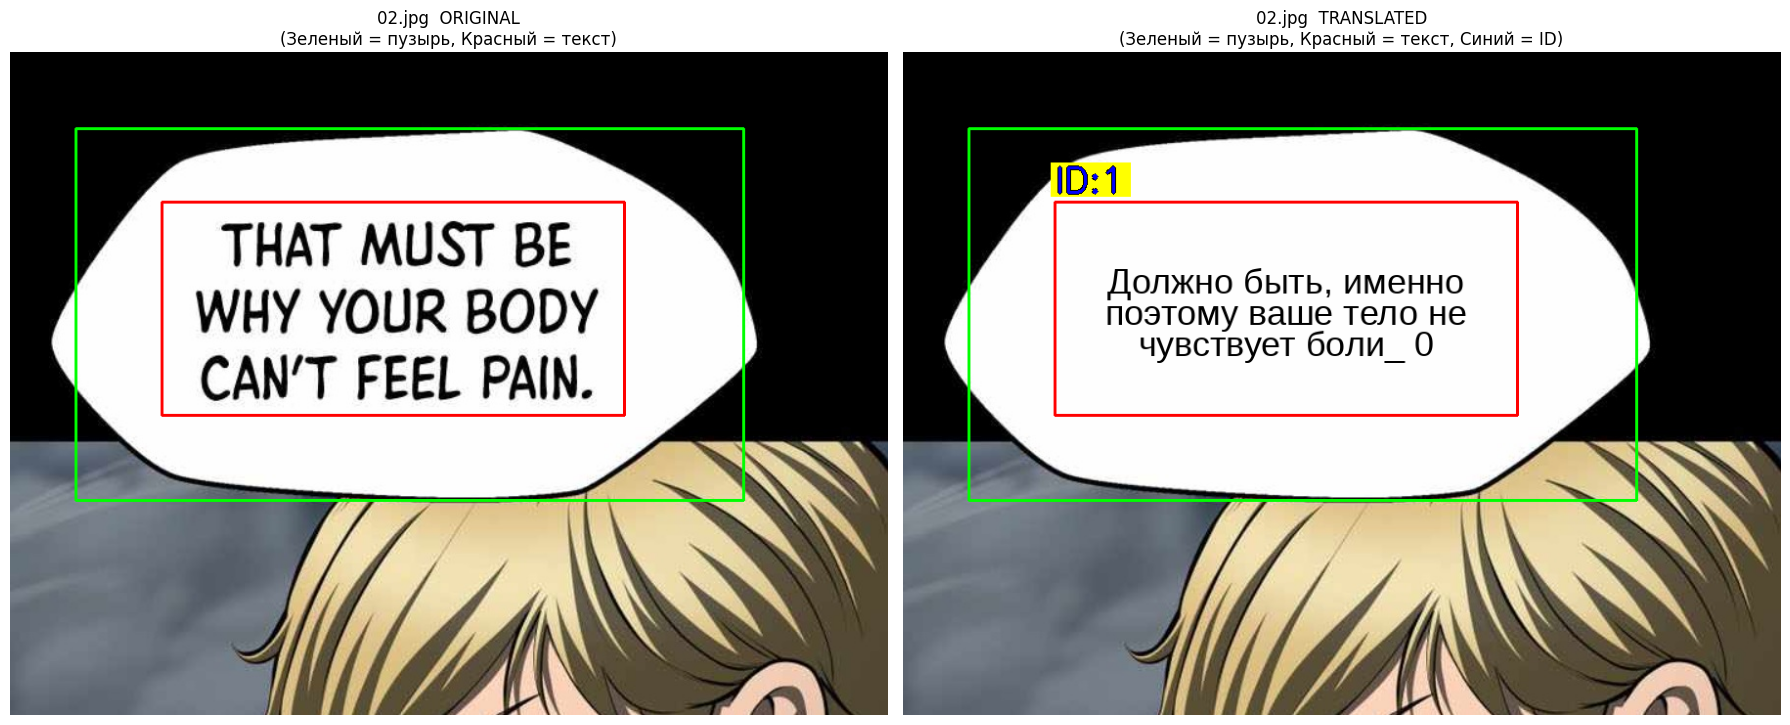


Страница 2/7
0 - редактировать
1 - сохранить и перейти дальше
2 - завершить работу
Ваш выбор: 0
Введите ID текста: 1

ID 1
Текущий текст:
Должно быть, именно поэтому ваше тело не чувствует боли_ 0
Новый текст (Enter = оставить без изменений): морковь


<Figure size 1800x900 with 0 Axes>

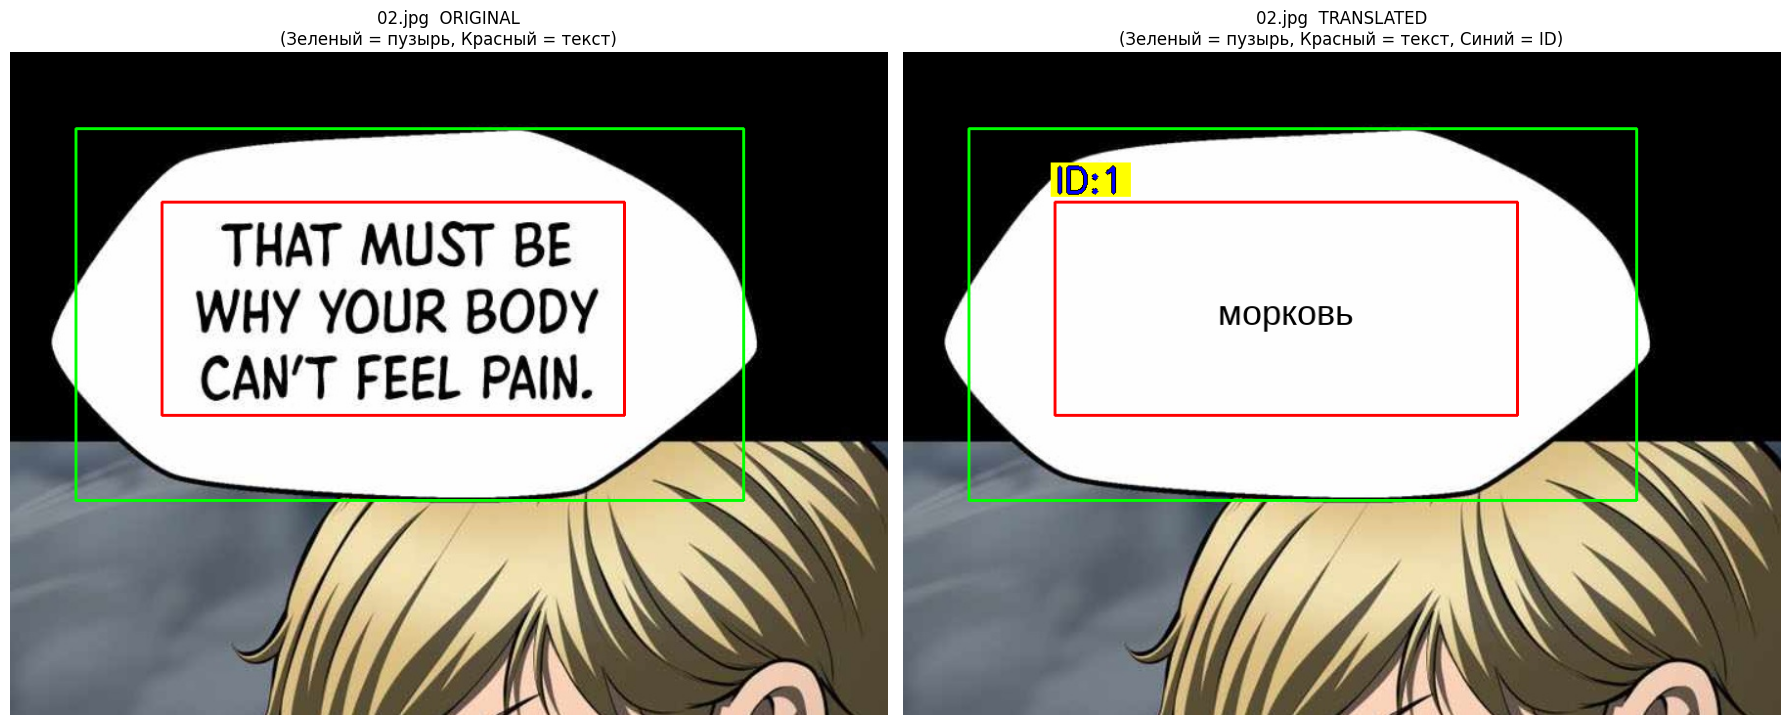


Продолжить редактирование?
0 - выбрать другой ID
1 - сохранить страницу и перейти дальше
2 - сохранить и закончить работу
Ваш выбор: 2
 JPEG сохранён: 02.jpg


<Figure size 1800x900 with 0 Axes>

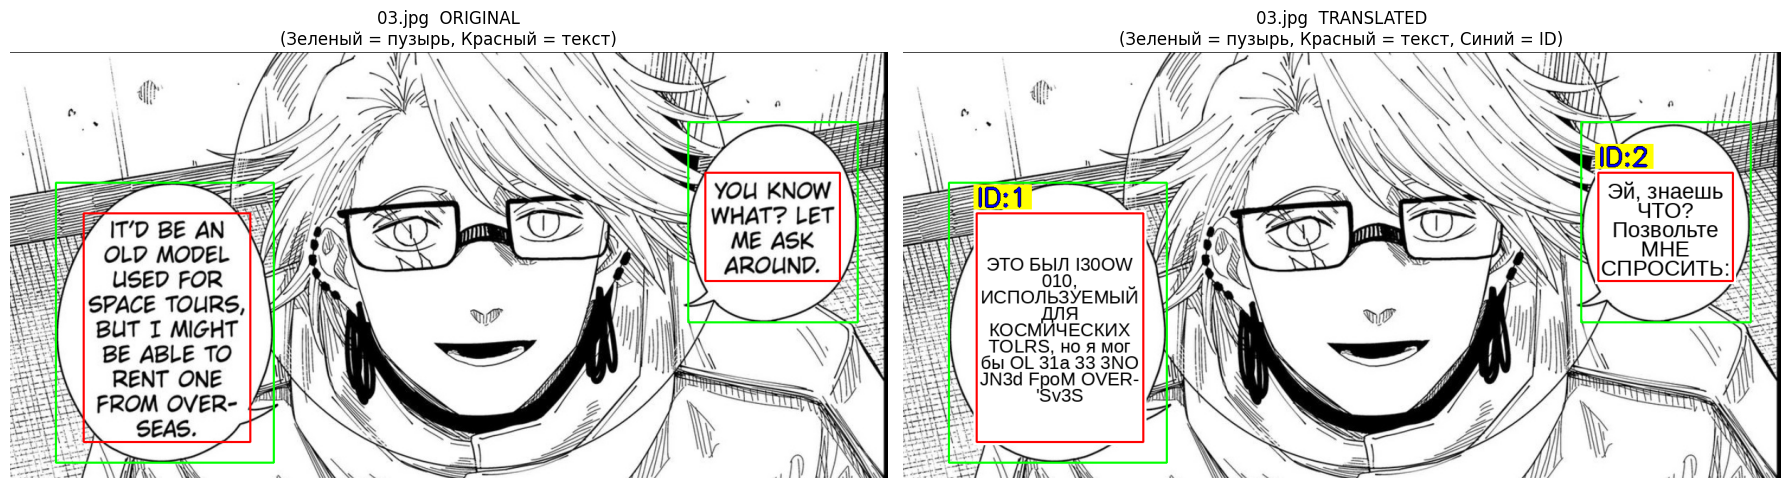


Страница 3/7
0 - редактировать
1 - сохранить и перейти дальше
2 - завершить работу
Ваш выбор: 0
Введите ID текста: 1

ID 1
Текущий текст:
ЭТО БЫЛ I30OW 010, ИСПОЛЬЗУЕМЫЙ ДЛЯ КОСМИЧЕСКИХ TOLRS, но я мог бы OL 31a 33 3NO JN3d FpoM OVER- 'Sv3S
Новый текст (Enter = оставить без изменений): привет


<Figure size 1800x900 with 0 Axes>

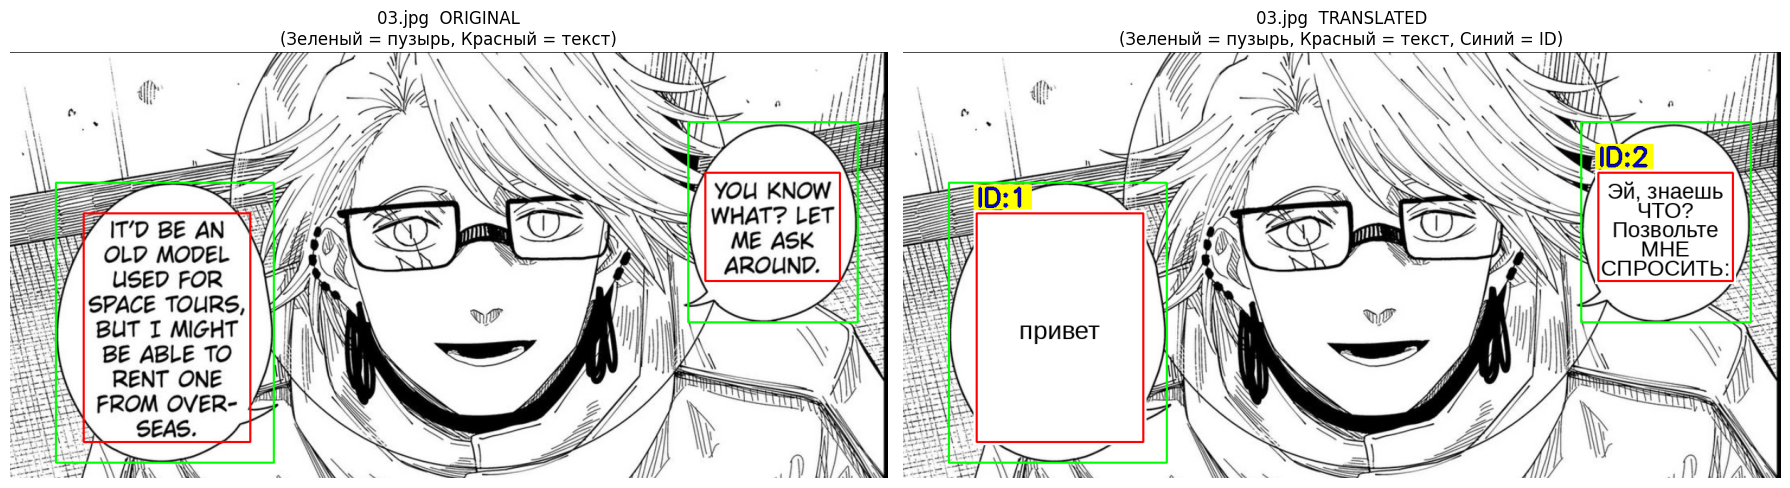


Продолжить редактирование?
0 - выбрать другой ID
1 - сохранить страницу и перейти дальше
2 - сохранить и закончить работу
Ваш выбор: 1
 JPEG сохранён: 03.jpg


<Figure size 1800x900 with 0 Axes>

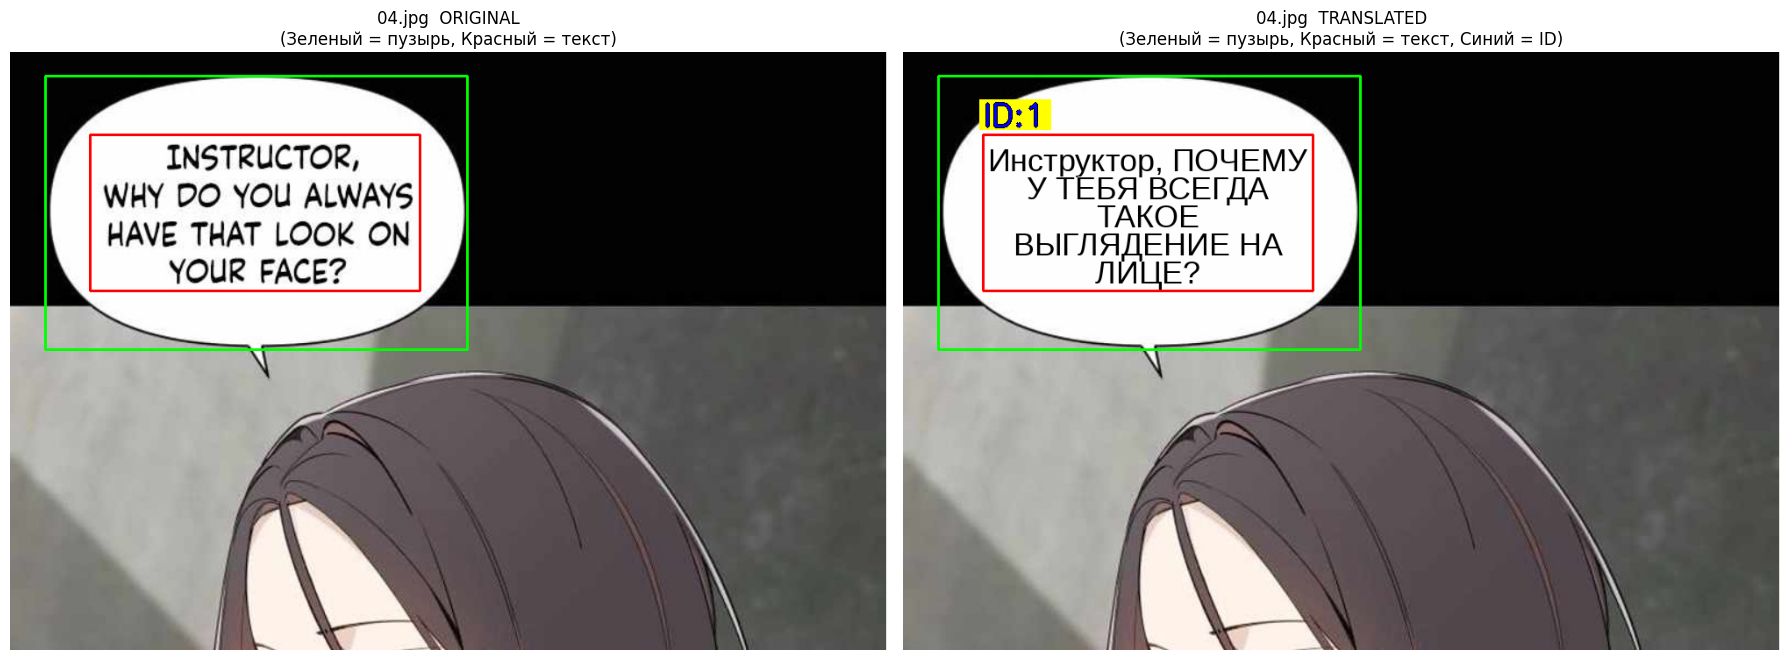


Страница 4/7
0 - редактировать
1 - сохранить и перейти дальше
2 - завершить работу
Ваш выбор: 2


In [46]:
# =====================================================
# РЕДАКТОР ПЕРЕВОДА
# БЛОК 1
# =====================================================

import os
import json
import cv2

# ---------------------------------------------
# количество страниц
# ---------------------------------------------

total_pages = len(pages)

print("=" * 60)
print(f"Всего страниц: {total_pages}")
print("=" * 60)

# ---------------------------------------------
# выбор страницы
# ---------------------------------------------

while True:

    try:

        start_page = int(
            input(
                f"Введите номер страницы для начала (1-{total_pages}): "
            )
        )

        if 1 <= start_page <= total_pages:
            break

    except:
        pass

    print("Неверный номер страницы.")

start_index = start_page - 1

# ---------------------------------------------
# поиск текста по ID
# ---------------------------------------------

def find_text_by_id(page, text_id):

    for bubble in page["texts"]:

        for text_box in bubble["texts"]:

            if text_box.get("text_id") == text_id:

                return bubble, text_box

    return None, None


# ---------------------------------------------
# сохранить jpeg
# ---------------------------------------------

def save_current_page(image_name, img):

    output_path = os.path.join(
        output_dir,
        image_name
    )

    cv2.imwrite(
        output_path,
        img,
        [cv2.IMWRITE_JPEG_QUALITY, 95]
    )

    print(f" JPEG сохранён: {image_name}")


# ---------------------------------------------
# сохранить json
# ---------------------------------------------

def save_json():

    json_path = os.path.join(
        output_dir,
        "translated_result.json"
    )

    with open(
        json_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            pages,
            f,
            ensure_ascii=False,
            indent=4
        )

    print()
    print("=" * 60)
    print("JSON сохранён:")
    print(json_path)
    print("=" * 60)

# =====================================================
# ОСНОВНОЙ ЦИКЛ ПО СТРАНИЦАМ
# =====================================================

stop_all = False

for page_index in range(start_index, total_pages):

    page = pages[page_index]

    image_name = page["image"]

    if image_name not in image_dict:
        print(f"Не найдено изображение {image_name}")
        continue

    img = cv2.imread(image_dict[image_name])

    if img is None:
        print(f"Ошибка чтения {image_name}")
        continue

    # ---------------------------------------------
    # первая отрисовка страницы
    # ---------------------------------------------

    img_clean_translated, fig = display_and_get_translated_image(
        img,
        page
    )

    plt.show(block=False)
    plt.pause(0.1)

    # ---------------------------------------------
    # спрашиваем что делать
    # ---------------------------------------------

    while True:

        print()
        print(f"Страница {page_index + 1}/{total_pages}")
        print("0 - редактировать")
        print("1 - сохранить и перейти дальше")
        print("2 - завершить работу")

        try:
            action = int(input("Ваш выбор: "))
        except:
            continue

        if action in (0, 1, 2):
            plt.close(fig)
            break

    # ---------------------------------------------
    # завершить программу
    # ---------------------------------------------

    if action == 2:
        stop_all = True
        break

    # ---------------------------------------------
    # сохранить без редактирования
    # ---------------------------------------------

    if action == 1:

        save_current_page(
            image_name,
            img_clean_translated
        )

        continue

    # =====================================================
    # ВНУТРЕННИЙ ЦИКЛ РЕДАКТИРОВАНИЯ
    # =====================================================

    while True:

        # ---------------------------------------------
        # выбор ID
        # ---------------------------------------------

        while True:

            try:
                text_id = int(input("Введите ID текста: "))
            except:
                print("Неверный ID.")
                continue

            bubble, text_box = find_text_by_id(page, text_id)

            if bubble is None:
                print("Такого ID нет.")
                continue

            break

        # ---------------------------------------------
        # текущий текст
        # ---------------------------------------------

        #old_text = text_box.get("edited_text", "").strip()
        old_text = bubble.get("edited_text", "").strip()

        if old_text == "":
            old_text = bubble.get("translated_text", "").strip()

        print()
        print("=" * 60)
        print(f"ID {text_id}")
        print("Текущий текст:")
        print(old_text)
        print("=" * 60)

        new_text = input(
            "Новый текст (Enter = оставить без изменений): "
        ).strip()

        if new_text != "":
            #text_box["edited_text"] = new_text
            bubble["edited_text"] = new_text

        # ---------------------------------------------
        # перерисовываем страницу
        # ---------------------------------------------

        img_clean_translated, fig = display_and_get_translated_image(
            img,
            page
        )

        plt.show(block=False)
        plt.pause(0.1)

        # ---------------------------------------------
        # продолжаем?
        # ---------------------------------------------

        while True:

            print()
            print("Продолжить редактирование?")
            print("0 - выбрать другой ID")
            print("1 - сохранить страницу и перейти дальше")
            print("2 - сохранить и закончить работу")

            try:
                answer = int(input("Ваш выбор: "))
            except:
                continue

            if answer in (0, 1, 2):
                plt.close(fig)
                break

        # ---------------------------------------------
        # снова выбрать ID этой же страницы
        # ---------------------------------------------

        if answer == 0:
            continue

        # ---------------------------------------------
        # сохранить jpeg
        # ---------------------------------------------

        save_current_page(
            image_name,
            img_clean_translated
        )

        # ---------------------------------------------
        # перейти к следующей странице
        # ---------------------------------------------

        if answer == 1:
            break

        # ---------------------------------------------
        # закончить полностью
        # ---------------------------------------------

        stop_all = True
        break